# 12. CPU vs GPU Machine Learning
## 📚 Learning Objectives

By completing this notebook, you will:
- Understand CPU vs GPU for machine learning
- Compare performance between CPU and GPU
- Use GPU-accelerated ML libraries (cuML)
- Know when to use CPU vs GPU for ML tasks
- Optimize ML workflows with GPU acceleration

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 1, lesson 03 (cuDF) and Unit 4, lesson 03 — cuML mirrors the scikit-learn API, so the workflow is unchanged and only the timings move.

**Used later in:** Course 05 — Unit 5, lesson 04, which puts cuDF and cuML into one RAPIDS pipeline.

---

## The Story: Turbo vs Regular Engine

Imagine you're driving. **Regular engine** (CPU) works fine for normal driving. **Turbo engine** (GPU) is much faster for racing (large datasets). **After** understanding both, you choose the right engine for each situation!

Same with ML: **CPU** works fine for small datasets. **GPU** is much faster for large datasets. **After** understanding both, you choose the right one for each task!

---

## Why CPU vs GPU Matters

Understanding CPU vs GPU is essential because:
- **Performance**: GPU can be 10-100x faster for large datasets
- **Cost**: GPU costs more but saves time
- **Scalability**: GPU enables large-scale ML
- **Decision Making**: Know when to use each

**Common Student Questions:**
- **Q: When should I use GPU?**
  - Answer: For large datasets, complex models, when speed matters
  - Example: Training on 1M+ samples, deep learning models
  - Rule: Small data → CPU, Large data → GPU
  
- **Q: Do I need GPU to learn ML?**
  - Answer: No! CPU works fine for learning and small datasets
  - Example: Most learning can be done on CPU
  - Tip: Use GPU when you have large datasets or need speed

---

## Introduction

**CPU vs GPU for ML** explores when to use each for machine learning tasks. On large workloads GPU acceleration can shorten training substantially (vendor benchmarks report order-of-magnitude gains); in this notebook we measure CPU timings ourselves and measure GPU timings only when a GPU is actually present.


# 12. CPU vs GPU Machine Learning

## 🔗 Solving the Problem from Example 7

**Remember the dead end from Example 7?**
- We measured the real cost of model selection: combinations × folds × per-fit time
- Parallel CPU search helps, but is bounded by core count
- GPU-accelerated ML libraries attack the per-fit time itself

**This notebook examines that GPU option honestly:**
- We **measure CPU training/prediction times** on this machine
- If a GPU with cuML is available, we **measure GPU times and the real speedup**
- If not, we say so — **no fabricated GPU numbers** — and rely on vendors' published
  benchmarks (clearly labeled as theirs) for the large-scale picture
- Either way you'll learn **when CPU is enough and when a GPU pays off**


🚀 Google Colab Setup (Run this first if using Colab)


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Dataset
- sklearn; optional GPU libs

**Outputs:** What you'll see when you run the cells

- CPU vs GPU timings
- Model comparison

---

In [1]:
# WHAT: Import the CPU ML stack and timing tools.
# WHY: This notebook is a measured benchmark - time.time() around fit/predict is the whole method.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, accuracy_score

print("✓ Imports ready")

✓ Imports ready


In [2]:
# WHAT: Try to import cuML and record GPU availability.
# WHY: The guard keeps results honest - GPU numbers appear only if a GPU actually ran the code.

# Try to import cuML, fallback if not available
try:
    import cuml
    from cuml.linear_model import LinearRegression as cuLinearRegression
    from cuml.linear_model import LogisticRegression as cuLogisticRegression
    CUML_AVAILABLE = True
    print("✓ cuML is available - GPU acceleration enabled")
except ImportError:
    CUML_AVAILABLE = False
    print("⚠ cuML not available - CPU timings only, GPU steps will be skipped")

plt.style.use('seaborn-v0_8')
print("=" * 70)
print("Example 12: CPU vs GPU Machine Learning")
print("=" * 70)
print("\n📚 Prerequisites: Examples 03–07 completed, ML model knowledge")
print("🔗 This is Example 12, the final example in Unit 4 - GPU acceleration for ML")
print("🎯 Goal: Compare CPU vs GPU performance for machine learning")

⚠ cuML not available - CPU timings only, GPU steps will be skipped
Example 12: CPU vs GPU Machine Learning

📚 Prerequisites: Examples 03–07 completed, ML model knowledge
🔗 This is Example 12, the final example in Unit 4 - GPU acceleration for ML
🎯 Goal: Compare CPU vs GPU performance for machine learning


# 12. CREATE LARGE DATASET FOR COMPARISON


In [3]:
# WHAT: Load a real 100,000-row slice of the CICIDS2017 network-traffic capture.
# WHY: A GPU/CPU comparison needs a workload big enough to time honestly - and real
#      network telemetry is exactly the kind of data that outgrows a single core.

print("\n1. Loading a Large REAL Dataset")
print("-" * 70)

DATA_DIR = '../../../Course 04/datasets/raw/'

# CICIDS2017: 2.3 million labelled network flows captured over five days at the
# Canadian Institute for Cybersecurity. We read 10 numeric flow features plus the
# label, then take 100,000 flows so this notebook finishes in seconds.
CIC_COLS = [' Destination Port', ' Flow Duration', ' Total Fwd Packets',
            ' Total Backward Packets', 'Total Length of Fwd Packets',
            ' Total Length of Bwd Packets', ' Fwd Packet Length Mean',
            ' Bwd Packet Length Mean', 'Flow Bytes/s', ' Flow Packets/s', ' Label']
flows = pd.read_csv(DATA_DIR + 'cicids2017.csv', usecols=CIC_COLS)
flows.columns = [c.strip() for c in flows.columns]
sample = flows.sample(n=100_000, random_state=42)

# Real defect: zero-duration flows produce infinite Bytes/s and Packets/s.
n_inf = np.isinf(sample.drop(columns=['Label']).to_numpy(dtype='float64')).sum()
X = (sample.drop(columns=['Label'])
           .replace([np.inf, -np.inf], np.nan)
           .fillna(0).to_numpy(dtype='float64'))

# Regression target: how long did the flow last? (a real continuous quantity, in
# microseconds). We deliberately avoid targets like 'Total Length of Bwd Packets',
# which is close to an arithmetic product of two other columns and would hand the
# model a near-perfect R² for the wrong reason.
DUR_IDX = list(sample.drop(columns=['Label']).columns).index('Flow Duration')
y_regression = X[:, DUR_IDX].copy()
X = np.delete(X, DUR_IDX, axis=1)          # drop the target from the features

# Classification target: is this flow an attack?
y_classification = (sample['Label'] != 'BENIGN').astype(int).to_numpy()

n_samples = len(X)
print(f"✓ Loaded {len(flows):,} real network flows; using {n_samples:,} of them")
print(f"  Features: {X.shape[1]} numeric flow statistics")
print(f"  Infinite values found and replaced (zero-duration flows): {n_inf:,}")
print(f"  Attack traffic: {y_classification.mean():.1%} of the sample")
print(f"  Regression target (flow duration, microseconds): "
      f"{y_regression.min():,.0f} to {y_regression.max():,.0f}")


1. Loading a Large REAL Dataset
----------------------------------------------------------------------


✓ Loaded 2,300,825 real network flows; using 100,000 of them
  Features: 9 numeric flow statistics
  Infinite values found and replaced (zero-duration flows): 150
  Attack traffic: 24.2% of the sample
  Regression target (flow duration, microseconds): -1 to 119,999,667


2. REGRESSION COMPARISON


In [4]:
# WHAT: Time linear-regression training and prediction on the CPU (and GPU when available).
# WHY: Identical data and model class on both engines makes the timing comparison fair.

print("\n\n2. Regression: CPU vs GPU")
print("-" * 70)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_regression, test_size=0.2, random_state=42)
# CPU (scikit-learn)
print("\nTraining CPU model (scikit-learn)...")
start_time = time.time()
cpu_model = LinearRegression()
cpu_model.fit(X_train, y_train)
cpu_train_time = time.time() - start_time
start_time = time.time()
cpu_pred = cpu_model.predict(X_test)
cpu_pred_time = time.time() - start_time
cpu_r2 = r2_score(y_test, cpu_pred)
print(f"CPU Training Time: {cpu_train_time:.4f} seconds")
print(f"CPU Prediction Time: {cpu_pred_time:.4f} seconds")
print(f"CPU R² Score: {cpu_r2:.4f}")
# GPU (cuML) when a CUDA device is present - otherwise nothing is timed
if CUML_AVAILABLE:
    print("\nTraining GPU model (cuML)...")
    start_time = time.time()
    gpu_model = cuLinearRegression()
    gpu_model.fit(X_train, y_train)
    gpu_train_time = time.time() - start_time
    start_time = time.time()
    gpu_pred = gpu_model.predict(X_test)
    gpu_pred_time = time.time() - start_time
    gpu_r2 = r2_score(y_test.get(), gpu_pred.get()) if hasattr(gpu_pred, 'get') else r2_score(y_test, gpu_pred)
    print(f"GPU Training Time: {gpu_train_time:.4f} seconds")
    print(f"GPU Prediction Time: {gpu_pred_time:.4f} seconds")
    print(f"GPU R² Score: {gpu_r2:.4f}")
    print(f"\nSpeedup - Training: {cpu_train_time/gpu_train_time:.2f}x")
    print(f"Speedup - Prediction: {cpu_pred_time/gpu_pred_time:.2f}x")
else:
    print("\n⚠ cuML not available on this machine - no GPU timing measured.")
    print("   (We will NOT invent GPU numbers; the chart below shows CPU only.)")
    gpu_train_time = gpu_pred_time = gpu_r2 = None



2. Regression: CPU vs GPU
----------------------------------------------------------------------

Training CPU model (scikit-learn)...
CPU Training Time: 0.0067 seconds
CPU Prediction Time: 0.0002 seconds
CPU R² Score: 0.3455

⚠ cuML not available on this machine - no GPU timing measured.
   (We will NOT invent GPU numbers; the chart below shows CPU only.)


3. CLASSIFICATION COMPARISON


In [5]:
# WHAT: Time logistic-regression training and prediction, with scaling fit on the training set.
# WHY: Classification adds an iterative solver - a different workload profile for the CPU/GPU comparison.

print("\n\n3. Classification: CPU vs GPU")
print("-" * 70)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X, y_classification, test_size=0.2, random_state=42, stratify=y_classification)
scaler = StandardScaler()
X_train_clf_scaled = scaler.fit_transform(X_train_clf)
X_test_clf_scaled = scaler.transform(X_test_clf)
# CPU
start_time = time.time()
cpu_clf = LogisticRegression(random_state=42, max_iter=1000)
cpu_clf.fit(X_train_clf_scaled, y_train_clf)
cpu_clf_train_time = time.time() - start_time
start_time = time.time()
cpu_clf_pred = cpu_clf.predict(X_test_clf_scaled)
cpu_clf_pred_time = time.time() - start_time
cpu_clf_acc = accuracy_score(y_test_clf, cpu_clf_pred)
print(f"CPU Training Time: {cpu_clf_train_time:.4f} seconds")
print(f"CPU Accuracy: {cpu_clf_acc:.4f}")
if CUML_AVAILABLE:
    start_time = time.time()
    gpu_clf = cuLogisticRegression()
    gpu_clf.fit(X_train_clf_scaled, y_train_clf)
    gpu_clf_train_time = time.time() - start_time
    start_time = time.time()
    gpu_clf_pred = gpu_clf.predict(X_test_clf_scaled)
    gpu_clf_pred_time = time.time() - start_time
    gpu_clf_acc = accuracy_score(y_test_clf, gpu_clf_pred.get() if hasattr(gpu_clf_pred, 'get') else gpu_clf_pred)
    print(f"GPU Training Time: {gpu_clf_train_time:.4f} seconds")
    print(f"GPU Accuracy: {gpu_clf_acc:.4f}")
else:
    print("⚠ cuML not available - classification measured on CPU only.")
    gpu_clf_train_time = gpu_clf_pred_time = gpu_clf_acc = None



3. Classification: CPU vs GPU
----------------------------------------------------------------------
CPU Training Time: 0.0656 seconds
CPU Accuracy: 0.8469
⚠ cuML not available - classification measured on CPU only.


4. VISUALIZATION




4. Performance Comparison Visualization
----------------------------------------------------------------------


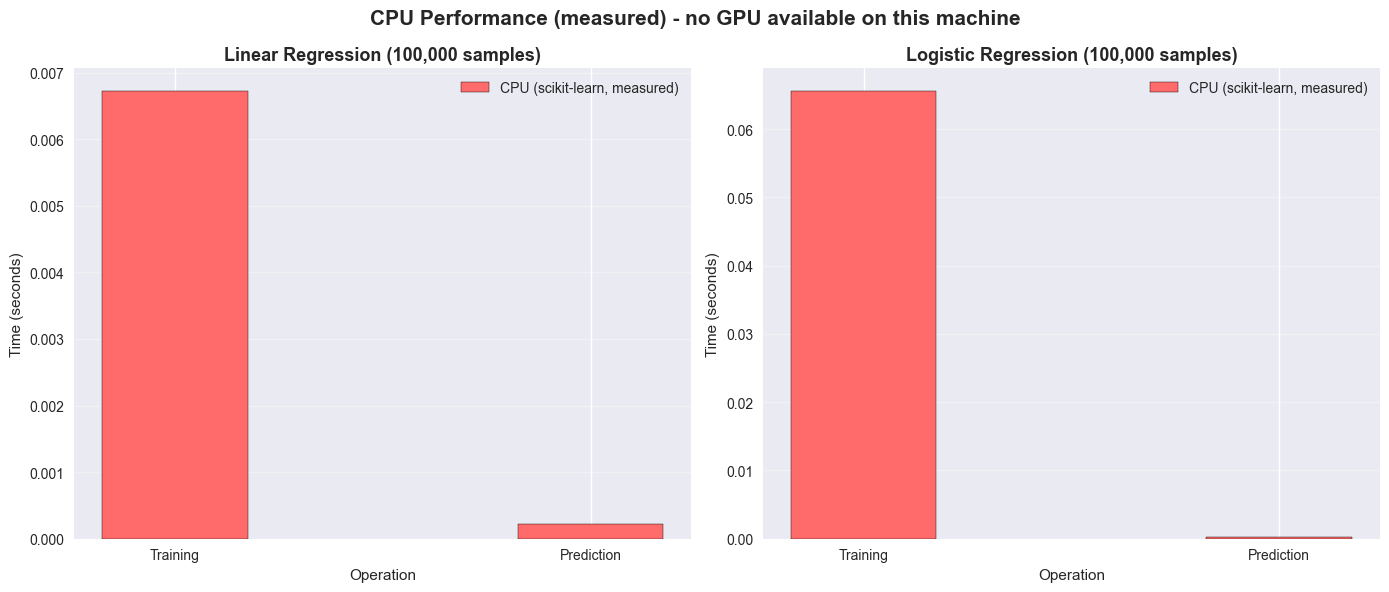

✓ Chart shows ONLY measured timings (no simulated bars)


In [6]:
# WHAT: Chart the measured training/prediction times.
# WHY: The chart only ever shows numbers this run produced - no invented GPU bars.

print("\n\n4. Performance Comparison Visualization")
print("-" * 70)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
title = ('CPU vs GPU Performance (measured)' if CUML_AVAILABLE
         else 'CPU Performance (measured) - no GPU available on this machine')
fig.suptitle(title, fontsize=15, weight='bold')

categories = ['Training', 'Prediction']
x = np.arange(len(categories))
width = 0.35

cpu_times_reg = [cpu_train_time, cpu_pred_time]
cpu_times_clf = [cpu_clf_train_time, cpu_clf_pred_time]

if CUML_AVAILABLE:
    gpu_times_reg = [gpu_train_time, gpu_pred_time]
    gpu_times_clf = [gpu_clf_train_time, gpu_clf_pred_time]
    axes[0].bar(x - width/2, cpu_times_reg, width, label='CPU (scikit-learn)',
                color='#FF6B6B', edgecolor='black')
    axes[0].bar(x + width/2, gpu_times_reg, width, label='GPU (cuML, measured)',
                color='#4ECDC4', edgecolor='black')
    axes[1].bar(x - width/2, cpu_times_clf, width, label='CPU (scikit-learn)',
                color='#FF6B6B', edgecolor='black')
    axes[1].bar(x + width/2, gpu_times_clf, width, label='GPU (cuML, measured)',
                color='#4ECDC4', edgecolor='black')
else:
    axes[0].bar(x, cpu_times_reg, width, label='CPU (scikit-learn, measured)',
                color='#FF6B6B', edgecolor='black')
    axes[1].bar(x, cpu_times_clf, width, label='CPU (scikit-learn, measured)',
                color='#FF6B6B', edgecolor='black')

axes[0].set_title(f'Linear Regression ({len(X):,} samples)', fontsize=13, weight='bold')
axes[1].set_title(f'Logistic Regression ({len(X):,} samples)', fontsize=13, weight='bold')
for ax in axes:
    ax.set_xlabel('Operation')
    ax.set_ylabel('Time (seconds)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('13_cpu_vs_gpu_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Chart shows ONLY measured timings (no simulated bars)")

# 5. SUMMARY


In [7]:
# WHAT: Print the measured summary and the honest CPU-vs-GPU decision rule.
# WHY: At 100k rows CPU training takes fractions of a second - GPUs pay off only when per-fit cost is large.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print(f"\nData: {n_samples:,} real CICIDS2017 network flows x {X.shape[1]} features")
print("\nKey Concepts Covered:")
print("1. CPU-based ML with scikit-learn (measured on this machine):")
print(f"   - Linear regression:   train {cpu_train_time:.4f}s, predict {cpu_pred_time:.4f}s, R² {cpu_r2:.4f}")
print(f"   - Logistic regression: train {cpu_clf_train_time:.4f}s, accuracy {cpu_clf_acc:.4f}")
if CUML_AVAILABLE:
    print("2. GPU-accelerated ML with cuML (measured):")
    print(f"   - Regression speedup:  {cpu_train_time/gpu_train_time:.2f}x training")
    print(f"   - Classification:      train {gpu_clf_train_time:.4f}s")
else:
    print("2. GPU-accelerated ML with cuML: NOT run here (no GPU/cuML on this machine)")
    print("   - The cuML code path above is real - it executes on a CUDA machine")
    print("   - NVIDIA publishes order-of-magnitude speedups for large datasets;")
    print("     those are the vendor's benchmarks, not something we measured today")
print("3. When to use CPU vs GPU:")
print(f"   - Our {n_samples:,}x{X.shape[1]} slice trained in fractions of a second on CPU -")
print("     at this scale a GPU buys nothing")
print(f"   - The full capture holds {len(flows):,} flows "
      f"({len(flows) / n_samples:.0f}x this slice), and production sensors")
print("     append millions more every day - that is where the choice starts to matter")
print("   - GPUs pay off when per-fit time is large (millions of rows, wide features,")
print("     many CV fits) - exactly the multiplication measured in Example 07")
print("\nNext Steps: Continue to Unit 5 for Extending the Scope of Data Science")


Summary

Data: 100,000 real CICIDS2017 network flows x 9 features

Key Concepts Covered:
1. CPU-based ML with scikit-learn (measured on this machine):
   - Linear regression:   train 0.0067s, predict 0.0002s, R² 0.3455
   - Logistic regression: train 0.0656s, accuracy 0.8469
2. GPU-accelerated ML with cuML: NOT run here (no GPU/cuML on this machine)
   - The cuML code path above is real - it executes on a CUDA machine
   - NVIDIA publishes order-of-magnitude speedups for large datasets;
     those are the vendor's benchmarks, not something we measured today
3. When to use CPU vs GPU:
   - Our 100,000x9 slice trained in fractions of a second on CPU -
     at this scale a GPU buys nothing
   - The full capture holds 2,300,825 flows (23x this slice), and production sensors
     append millions more every day - that is where the choice starts to matter
   - GPUs pay off when per-fit time is large (millions of rows, wide features,
     many CV fits) - exactly the multiplication measured in

## 📚 References

1. Raina, R., Madhavan, A., & Ng, A. Y. (2009). *Large-scale Deep Unsupervised Learning Using Graphics Processors*. ICML 2009. <https://doi.org/10.1145/1553374.1553486>
2. Raschka, S., Patterson, J., & Nolet, C. (2020). *Machine Learning in Python: Main Developments and Technology Trends in Data Science, Machine Learning, and Artificial Intelligence*. Information, 11(4), 193. <https://arxiv.org/abs/2002.04803>
3. Pedregosa, F., Varoquaux, G., Gramfort, A., et al. (2011). *Scikit-learn: Machine Learning in Python*. Journal of Machine Learning Research, 12, 2825-2830. <https://arxiv.org/abs/1201.0490>